# Workforce Analytics & Retention Insights

## Executive Summary

### Business Question

Which workforce characteristics are associated with employee attrition,
and how can workforce data support responsible, evidence-informed
retention analysis?

### Dataset

The analysis uses the **IBM HR Analytics Employee Attrition & Performance**
dataset, a fictional workforce dataset created by IBM data scientists and
made publicly available through Kaggle.

The dataset contains 1,470 employee records and 35 variables, including
information on employee demographics, job characteristics, compensation,
satisfaction, business travel, overtime, training and career development.

The target variable is **Attrition**, with 16.1% of records representing
observed attrition and 83.9% non-attrition.

The dataset contains no missing values. Several administrative variables
with no analytical variation or individual identifier function were
excluded from the analysis.

Because the data is synthetic, the findings should not be interpreted as
evidence about a real organization. The dataset is used here as a controlled
case study to demonstrate hypothesis-driven workforce analytics,
multivariate modelling and responsible interpretation.

**Source:** IBM HR Analytics Employee Attrition & Performance  
**Provider:** IBM / IBM Watson Analytics sample data  
**Public dataset:** Kaggle – IBM HR Analytics Employee Attrition & Performance: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

### Analytical Approach

The analysis combines:

- data quality and structure checks
- hypothesis-driven exploratory data analysis
- group comparisons and normalized attrition rates
- feature binning and quartile analysis
- correlation and stratified analysis
- multivariate logistic regression
- model evaluation under class imbalance
- coefficient and odds-ratio interpretation
- classification-threshold analysis

### Key Findings

Several workforce characteristics show meaningful associations with
observed attrition.

- Employees working overtime show 30.5% attrition compared with 10.4%
  among employees without overtime.
- Frequent business travellers show 24.9% attrition compared with 8.0%
  among non-travellers.
- Sales Representatives show the highest observed role-specific
  attrition rate at 39.8%.
- Employees in the lowest income quartile show 29.3% attrition.
- Low job and environment satisfaction are associated with higher
  observed attrition.
- Years since last promotion shows no consistent relationship with
  attrition.

Several of these patterns remain visible in the multivariate logistic
regression. Overtime, frequent business travel and selected job roles
show positive associations, while monthly income and satisfaction
measures show negative associations with attrition.

### Model Performance

The logistic regression achieves a ROC-AUC of 0.768.

However, at the default classification threshold, recall for observed
attrition is only 21.3%. This demonstrates why overall accuracy alone
is insufficient for evaluating an imbalanced workforce dataset.

The model is therefore used primarily to understand multivariate
associations rather than to predict individual employee behaviour.

### Responsible Use

The analysis does not establish causal relationships and should not be
used to label individual employees as "flight risks" or to automate
employment decisions.

The results are intended to support organizational investigation into
workload, travel, role-specific conditions, compensation structures and
employee experience.

Quantitative findings should be combined with organizational context,
employee feedback and human judgment before retention measures are
designed.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.shape

(1470, 35)

### Dataset Size

The dataset contains 1,470 employee records and 35 variables.
Each row represents one synthetic employee.

In [3]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
# 1. Doppelte vollständige Datensätze
df.duplicated().sum()

np.int64(0)

In [7]:
# 2. Anzahl unterschiedlicher Werte pro Variable
df.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [8]:
# 3. Verteilung unserer Zielvariable
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [9]:
df["Attrition"].value_counts(normalize=True).mul(100).round(1)

,proportion
Attrition,
No,83.9
Yes,16.1


## Initial Data Quality Findings

- The dataset contains 1,470 employee records and 35 variables.
- No missing values were identified in the initial null-value check.
- `EmployeeNumber` appears to be a unique employee identifier.
- `EmployeeCount`, `Over18`, and `StandardHours` are constant variables
  and therefore provide no discriminatory information for the analysis.
- The observed attrition rate is 16.1%.
- The target variable is imbalanced: 83.9% of records are classified as
  `No` and 16.1% as `Yes`.
- This class imbalance will need to be considered when evaluating
  classification models later in the project.

## Business Questions

The workforce analysis focuses on the following organizational questions:

1. **Workload and working conditions**
   - Is attrition associated with overtime, business travel and work-life balance?

2. **Career development**
   - Is attrition associated with career progression, training, job level and time since promotion?

3. **Organizational role**
   - Do attrition rates differ across departments and job roles?

4. **Compensation**
   - Is attrition associated with monthly income, salary increases and stock option levels?

5. **Communication**
   - Communication is considered potentially relevant to employee retention,
     but it is not directly measured in the available dataset.
   - This will therefore be documented as a limitation rather than inferred
     from unrelated variables.
     

In [10]:
pd.crosstab(df["OverTime"], df["Attrition"])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [11]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

overtime_attrition.round(1)

Attrition,No,Yes
OverTime,,
No,89.6,10.4
Yes,69.5,30.5


### Workload: Overtime and Attrition

Employees with overtime show an attrition rate of 30.5%, compared with
10.4% among employees without overtime.

This represents a difference of 20.1 percentage points.

In this synthetic dataset, overtime is therefore associated with
substantially higher observed attrition.

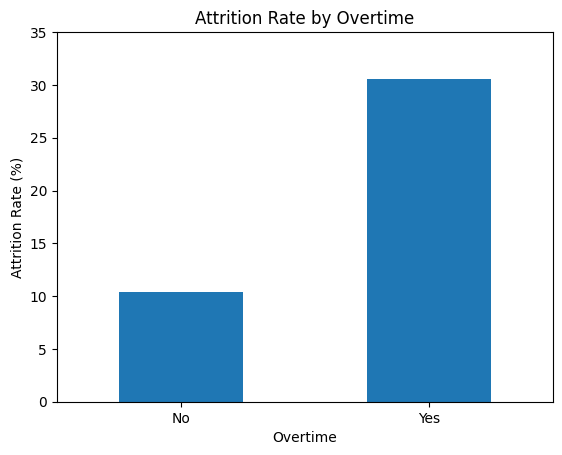

In [12]:
import matplotlib.pyplot as plt

attrition_by_overtime = overtime_attrition["Yes"]

attrition_by_overtime.plot(kind="bar")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 35)

plt.show()

In [13]:
df["BusinessTravel"].value_counts()

,count
BusinessTravel,
Travel_Rarely,1043
Travel_Frequently,277
Non-Travel,150


In [14]:
df["BusinessTravel"].value_counts(normalize=True).mul(100).round(1)

,proportion
BusinessTravel,
Travel_Rarely,71.0
Travel_Frequently,18.8
Non-Travel,10.2


In [15]:
pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"]
)

Attrition,No,Yes
BusinessTravel,,
Non-Travel,138,12
Travel_Frequently,208,69
Travel_Rarely,887,156


In [16]:
travel_attrition = pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
) * 100

In [17]:
travel_attrition.round(1)


Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.0,8.0
Travel_Frequently,75.1,24.9
Travel_Rarely,85.0,15.0


### Business Travel and Attrition

Attrition rates increase with the frequency of business travel:

- Non-Travel: 8.0%
- Travel_Rarely: 15.0%
- Travel_Frequently: 24.9%

In this synthetic dataset, more frequent business travel is associated
with higher observed attrition. Employees who travel frequently show
the highest attrition rate.

This finding indicates an association, not a causal relationship.

In [18]:
df["WorkLifeBalance"].value_counts().sort_index()

,count
WorkLifeBalance,
1,80
2,344
3,893
4,153


In [19]:
df["WorkLifeBalance"].value_counts(
    normalize=True
).sort_index().mul(100).round(1)

,proportion
WorkLifeBalance,
1,5.4
2,23.4
3,60.7
4,10.4


We expect employees with a lower work-life balance rating to have a higher attrition rate.

In [20]:
wlb_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

wlb_attrition.round(1)

Attrition,No,Yes
WorkLifeBalance,,
1,68.8,31.2
2,83.1,16.9
3,85.8,14.2
4,82.4,17.6


### Work-Life Balance and Attrition

Employees with the lowest work-life balance rating show the highest
attrition rate at 31.2%.

Attrition is considerably lower for employees with work-life balance
ratings of 2 (16.9%), 3 (14.2%), and 4 (17.6%).

Overall, poor work-life balance is associated with higher observed
attrition in this synthetic dataset. However, the relationship is not
strictly linear, as the attrition rate increases slightly from 14.2%
for rating 3 to 17.6% for rating 4.

This finding indicates an association and should not be interpreted
as evidence that work-life balance causes employee attrition.

## Interim Findings: Workload and Working Conditions

The initial analysis suggests that working conditions are associated
with meaningful differences in observed attrition:

- Employees working overtime show substantially higher attrition
  (30.5%) than employees without overtime (10.4%).
- Frequent business travellers show higher attrition (24.9%) than
  employees who travel rarely (15.0%) or do not travel (8.0%).
- Employees reporting the lowest work-life balance show the highest
  attrition rate (31.2%), although the relationship is not strictly
  linear across all work-life balance categories.

These findings identify areas for further analysis but do not establish
causal relationships.

## Career Development and Attrition

### Business Question

Is employee attrition associated with career development and progression opportunities?

### Hypothesis

I expect higher attrition among employees with fewer development opportunities
or limited career progression.

In [23]:
df["YearsSinceLastPromotion"].describe()

,YearsSinceLastPromotion
count,1470.000000
mean,2.187755
std,3.222430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,15.000000


In [24]:
df["YearsSinceLastPromotion"].value_counts().sort_index()

,count
YearsSinceLastPromotion,
0,581
1,357
2,159
3,52
4,61
5,45
6,32
7,76
8,18


#### Analytical Grouping

`YearsSinceLastPromotion` ranges from 0 to 15 years, with most observations
concentrated at the lower end of the distribution.

To avoid overinterpreting attrition rates for individual years with small
sample sizes, the variable is grouped into four analytical categories:

- 0 years
- 1–2 years
- 3–5 years
- 6+ years

These categories are created for exploratory analysis and are not predefined
categories in the original dataset.

In [26]:
df["PromotionGapGroup"] = pd.cut(
    df["YearsSinceLastPromotion"],
    bins=[-1, 0, 2, 5, float("inf")],
    labels=["0 years", "1–2 years", "3–5 years", "6+ years"]
)

In [27]:
df["PromotionGapGroup"].value_counts().sort_index()

,count
PromotionGapGroup,
0 years,581
1–2 years,516
3–5 years,158
6+ years,215


In [28]:
promotion_attrition = pd.crosstab(
    df["PromotionGapGroup"],
    df["Attrition"],
    normalize="index"
) * 100

promotion_attrition.round(1)

Attrition,No,Yes
PromotionGapGroup,,
0 years,81.1,18.9
1–2 years,85.3,14.7
3–5 years,89.9,10.1
6+ years,83.7,16.3


#### Finding: Years Since Last Promotion

The hypothesis of steadily increasing attrition with a longer time since
the last promotion is not supported by the data.

Attrition is highest among employees with 0 years since their last
promotion (18.9%), decreases to 14.7% for 1–2 years and 10.1% for
3–5 years, and then increases again to 16.3% among employees with
6+ years since their last promotion.

The relationship is therefore non-linear. In this synthetic dataset,
time since the last promotion alone does not show a clear pattern of
increasing attrition.

Further analysis would be needed to understand whether these differences
are related to other factors such as tenure, job level or role.

### Training and Development

**Business Question:**  
Is participation in training associated with employee attrition?

**Hypothesis:**  
I expect employees with more training opportunities to show lower attrition
rates than employees with little or no training.

In [29]:
df["TrainingTimesLastYear"].describe()

,TrainingTimesLastYear
count,1470.000000
mean,2.799320
std,1.289271
min,0.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,6.000000


In [30]:
df["TrainingTimesLastYear"].value_counts().sort_index()

,count
TrainingTimesLastYear,
0,54
1,71
2,547
3,491
4,123
5,119
6,65


In [31]:
df["TrainingTimesLastYear"].value_counts(
    normalize=True
).sort_index().mul(100).round(1)

,proportion
TrainingTimesLastYear,
0,3.7
1,4.8
2,37.2
3,33.4
4,8.4
5,8.1
6,4.4


#### Analytical Grouping

Training frequency ranges from 0 to 6 times in the previous year.

Because some individual training-frequency categories contain relatively
few observations, the variable is grouped into three categories for
exploratory analysis:

- **Low:** 0–1 training sessions
- **Moderate:** 2–3 training sessions
- **High:** 4–6 training sessions

These categories are created for exploratory analysis and are not predefined
categories in the original dataset.

In [32]:
df["TrainingGroup"] = pd.cut(
    df["TrainingTimesLastYear"],
    bins=[-1, 1, 3, 6],
    labels=["Low (0–1)", "Moderate (2–3)", "High (4–6)"]
)

In [33]:
df["TrainingGroup"].value_counts().sort_index()

,count
TrainingGroup,
Low (0–1),125
Moderate (2–3),1038
High (4–6),307


In [34]:
df["TrainingGroup"].value_counts().sum()

np.int64(1470)

In [35]:
training_attrition = pd.crosstab(
    df["TrainingGroup"],
    df["Attrition"],
    normalize="index"
) * 100

training_attrition.round(1)

Attrition,No,Yes
TrainingGroup,,
Low (0–1),80.8,19.2
Moderate (2–3),83.9,16.1
High (4–6),85.0,15.0


#### Finding: Training and Attrition

The hypothesis is supported by the exploratory results.

Employees in the low-training group (0–1 training sessions) show the
highest attrition rate at 19.2%. Attrition decreases to 16.1% among
employees with moderate training participation (2–3 sessions) and to
15.0% among employees in the high-training group (4–6 sessions).

This represents a difference of 4.2 percentage points between the low-
and high-training groups.

In this synthetic dataset, higher training participation is therefore
associated with moderately lower observed attrition. However, the
difference is relatively small and does not establish that additional
training causes lower attrition.

### Job Level and Career Progression

**Business Question:**  
Do attrition rates differ across job levels?

**Hypothesis:**  
I expect employees at lower job levels to show higher attrition rates
than employees at higher job levels.

Job level may, however, be related to other factors such as income,
tenure and age. Any observed relationship should therefore not be
interpreted as an isolated effect of job level.

In [37]:
df["JobLevel"].value_counts().sort_index()

,count
JobLevel,
1,543
2,534
3,218
4,106
5,69


In [38]:
df["JobLevel"].value_counts(
    normalize=True
).sort_index().mul(100).round(1)

,proportion
JobLevel,
1,36.9
2,36.3
3,14.8
4,7.2
5,4.7


In [41]:
joblevel_attrition = pd.crosstab(
    df["JobLevel"],
    df["Attrition"],
    normalize="index"
) * 100

joblevel_attrition.round(1)

Attrition,No,Yes
JobLevel,,
1,73.7,26.3
2,90.3,9.7
3,85.3,14.7
4,95.3,4.7
5,92.8,7.2


#### Finding: Job Level and Attrition

Employees at Job Level 1 show the highest observed attrition rate at
26.3%.

Attrition is substantially lower at higher job levels, although the
relationship is not strictly linear:

- Job Level 1: 26.3%
- Job Level 2: 9.7%
- Job Level 3: 14.7%
- Job Level 4: 4.7%
- Job Level 5: 7.2%

The hypothesis is therefore partially supported. Lower job level,
particularly Job Level 1, is associated with higher observed attrition
in this synthetic dataset, but attrition does not decrease consistently
with every increase in job level.

Job level may also be related to other factors such as income, tenure
and age, which should be considered in further analysis.

## Compensation and Attrition

### Business Question

Is employee attrition associated with compensation levels?

### Hypothesis

I expect employees with lower monthly income to show higher observed
attrition rates than employees with higher monthly income.

However, monthly income is likely to be related to other workforce
characteristics such as job level, role, age and tenure. Any observed
relationship should therefore not be interpreted as an isolated effect
of compensation.

In [42]:
df["MonthlyIncome"].describe()

,MonthlyIncome
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000


In [43]:
df["MonthlyIncome"].nunique()

1349

In [44]:
df.groupby("Attrition")["MonthlyIncome"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.7,4818.2,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.1,3640.2,1009.0,2373.0,3202.0,5916.0,19859.0


### Finding: Monthly Income and Attrition

Employees who left the organization show substantially lower monthly
income than employees who remained.

- Mean monthly income:
  - No Attrition: 6,832.7
  - Attrition: 4,787.1

- Median monthly income:
  - No Attrition: 5,204
  - Attrition: 3,202

Both the mean and median indicate lower monthly income among employees
with observed attrition.

In this synthetic dataset, lower monthly income is therefore associated
with higher observed attrition. However, this relationship should not
be interpreted as causal, as income is likely related to other factors
such as job level, role, age and tenure.

In [48]:
df.groupby("JobLevel")["MonthlyIncome"].agg(
    ["count", "mean", "median"]
).round(1)

,count,mean,median
JobLevel,,,
1,543,2786.9,2670.0
2,534,5502.3,5340.0
3,218,9817.3,9980.0
4,106,15503.8,16154.0
5,69,19191.8,19232.0


### Job Level and Monthly Income

**Hypothesis:**  
I expect monthly income to increase with job level.

This analysis helps assess whether the previously observed relationships
between job level, income and attrition may reflect overlapping workforce
structures rather than independent effects.

### Finding: Job Level and Monthly Income

Monthly income increases substantially with job level. Median monthly
income rises from 2,670 at Job Level 1 to 19,232 at Job Level 5.

This indicates a strong relationship between job level and compensation
in the synthetic workforce dataset.

The previously observed higher attrition among lower-income employees
and employees at lower job levels may therefore reflect overlapping
workforce structures rather than two independent effects.

Further multivariate analysis is needed before drawing conclusions about
the individual contribution of job level or compensation to attrition.

In [49]:
df[["JobLevel", "MonthlyIncome"]].corr().round(2)

,JobLevel,MonthlyIncome
JobLevel,1.00,0.95
MonthlyIncome,0.95,1.00


#### Correlation: Job Level and Monthly Income

Job level and monthly income show a very strong positive correlation
(r = 0.95).

This confirms that compensation is closely related to job level in the
synthetic workforce dataset.

Therefore, the previously observed associations between lower job level,
lower monthly income and higher attrition should not be treated as
independent effects.

Further multivariate analysis will be needed to assess how these related
factors contribute to observed attrition patterns.

In [50]:
df["MonthlyIncome"].quantile([0.25, 0.50, 0.75]).round(0)

,MonthlyIncome
0.25,2911.0
0.50,4919.0
0.75,8379.0


### Income Groups and Attrition

**Hypothesis:**  
I expect employees in the lower income quartiles to show higher observed
attrition rates than employees in the higher income quartiles.

Income quartiles will be used to create similarly sized comparison groups
without imposing arbitrary income thresholds.

In [52]:
df["IncomeQuartile"] = pd.qcut(
    df["MonthlyIncome"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2 - Lower-middle",
        "Q3 - Upper-middle",
        "Q4 - Highest"
    ]
)

In [53]:
df["IncomeQuartile"].value_counts().sort_index()

,count
IncomeQuartile,
Q1 - Lowest,369
Q2 - Lower-middle,366
Q3 - Upper-middle,367
Q4 - Highest,368


In [54]:
df.groupby("IncomeQuartile", observed=True)["MonthlyIncome"].agg(
    ["min", "max", "median", "count"]
).round(1)

,min,max,median,count
IncomeQuartile,,,,
Q1 - Lowest,1009,2911,2379.0,369
Q2 - Lower-middle,2926,4908,4032.0,366
Q3 - Upper-middle,4930,8376,6077.0,367
Q4 - Highest,8380,19999,13118.0,368


In [55]:
income_attrition = pd.crosstab(
    df["IncomeQuartile"],
    df["Attrition"],
    normalize="index"
) * 100

income_attrition.round(1)

Attrition,No,Yes
IncomeQuartile,,
Q1 - Lowest,70.7,29.3
Q2 - Lower-middle,85.8,14.2
Q3 - Upper-middle,89.4,10.6
Q4 - Highest,89.7,10.3


### Finding: Income Quartiles and Attrition

The hypothesis is supported by the exploratory results.

Employees in the lowest income quartile show the highest observed
attrition rate at 29.3%. Attrition is considerably lower in the
remaining income groups:

- Q1 - Lowest: 29.3%
- Q2 - Lower-middle: 14.2%
- Q3 - Upper-middle: 10.6%
- Q4 - Highest: 10.3%

The largest difference occurs between the lowest and second income
quartiles (15.1 percentage points), while attrition rates differ only
slightly between the two highest income quartiles.

This suggests that the lowest income group is particularly associated
with higher observed attrition in this synthetic dataset. However,
income is strongly related to job level and other workforce
characteristics, so this relationship should not be interpreted as
causal or independent.

In [56]:
pd.crosstab(
    df["JobLevel"],
    df["IncomeQuartile"]
)

IncomeQuartile,Q1 - Lowest,Q2 - Lower-middle,Q3 - Upper-middle,Q4 - Highest
JobLevel,,,,
1,356,183,4,0
2,13,183,309,29
3,0,0,54,164
4,0,0,0,106
5,0,0,0,69


#### Finding: Job Level and Income Structure

Income quartiles are strongly structured by job level.

The lowest income quartile is almost entirely composed of employees
at Job Level 1, while employees at Job Levels 4 and 5 are exclusively
represented in the highest income quartile.

This pattern is consistent with the previously observed strong
correlation between JobLevel and MonthlyIncome (r = 0.95).

As a result, the higher attrition observed among lower-income employees
cannot be interpreted independently from job level. The two variables
capture substantially overlapping workforce structures.

In [57]:
level1 = df[
    (df["JobLevel"] == 1) &
    (df["IncomeQuartile"].isin(["Q1 - Lowest", "Q2 - Lower-middle"]))
].copy()

level1_income_attrition = pd.crosstab(
    level1["IncomeQuartile"],
    level1["Attrition"],
    normalize="index"
) * 100

level1_income_attrition.round(1)

Attrition,No,Yes
IncomeQuartile,,
Q1 - Lowest,69.9,30.1
Q2 - Lower-middle,80.9,19.1


### Finding: Income and Attrition Within Job Level 1

To reduce the overlap between job level and income, attrition was
compared within Job Level 1.

Within the same job level, employees in the lowest income quartile
show an attrition rate of 30.1%, compared with 19.1% among employees
in the lower-middle income quartile.

This difference of 11.0 percentage points suggests that the previously
observed association between lower income and higher attrition is not
explained solely by job level.

However, this stratified comparison does not establish an independent
or causal effect of compensation. Other employee characteristics may
still differ between the two groups and should be considered in
multivariate analysis.

## Job Role and Attrition

### Business Question

Do observed attrition rates differ across job roles?

### Hypothesis

I expect attrition rates to vary across job roles because roles may
differ in working conditions, career opportunities, compensation and
other organizational characteristics.

Any differences between roles should therefore be interpreted as
descriptive patterns rather than effects caused by the role itself.

In [58]:
df["JobRole"].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


In [60]:
df["JobRole"].value_counts(
    normalize=True
).mul(100).round(1)

,proportion
JobRole,
Sales Executive,22.2
Research Scientist,19.9
Laboratory Technician,17.6
Manufacturing Director,9.9
Healthcare Representative,8.9
Manager,6.9
Sales Representative,5.6
Research Director,5.4
Human Resources,3.5


In [61]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition.round(1)

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.1,6.9
Human Resources,76.9,23.1
Laboratory Technician,76.1,23.9
Manager,95.1,4.9
Manufacturing Director,93.1,6.9
Research Director,97.5,2.5
Research Scientist,83.9,16.1
Sales Executive,82.5,17.5
Sales Representative,60.2,39.8


In [62]:
jobrole_attrition.sort_values(
    by="Yes",
    ascending=False
).round(1)

Attrition,No,Yes
JobRole,,
Sales Representative,60.2,39.8
Laboratory Technician,76.1,23.9
Human Resources,76.9,23.1
Sales Executive,82.5,17.5
Research Scientist,83.9,16.1
Manufacturing Director,93.1,6.9
Healthcare Representative,93.1,6.9
Manager,95.1,4.9
Research Director,97.5,2.5


## Attrition by Job Role

Observed attrition rates differ substantially across job roles.
The chart highlights organizational areas that may warrant deeper
investigation rather than implying that job role itself causes attrition.

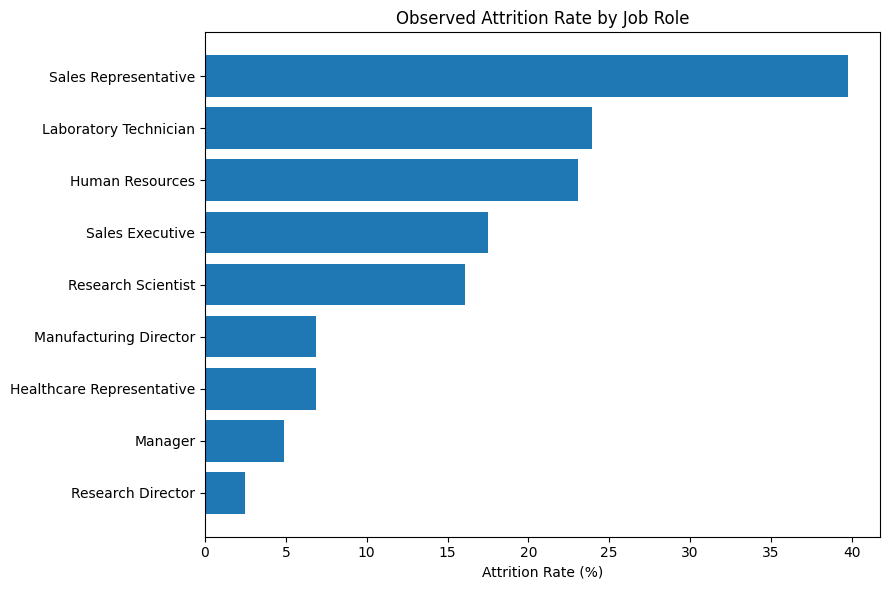

In [94]:
jobrole_plot = (
    jobrole_attrition["Yes"]
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    jobrole_plot.index,
    jobrole_plot.values
)

plt.xlabel("Attrition Rate (%)")
plt.ylabel("")
plt.title("Observed Attrition Rate by Job Role")

plt.tight_layout()
plt.show()

### Finding: Job Role and Attrition

Observed attrition rates vary substantially across job roles.

The highest attrition rates are observed among:

- Sales Representative: 39.8%
- Laboratory Technician: 23.9%
- Human Resources: 23.1%

The lowest observed attrition rates occur among:

- Research Director: 2.5%
- Manager: 4.9%
- Healthcare Representative: 6.9%
- Manufacturing Director: 6.9%

The difference between the highest and lowest observed attrition rates
is 37.3 percentage points.

These results suggest that job role is associated with substantial
differences in observed attrition in this synthetic dataset. However,
job roles may also differ in compensation, job level, overtime,
business travel and other workforce characteristics.

The results should therefore be interpreted as descriptive patterns
rather than evidence that a particular job role causes attrition.

## Satisfaction and Attrition

### Business Question

Is employee satisfaction associated with observed attrition?

### Hypothesis

I expect employees reporting lower job or environmental satisfaction
to show higher observed attrition rates.

These variables represent self-reported satisfaction levels. Any observed
relationship should be interpreted as an association rather than evidence
that dissatisfaction causes attrition.

In [63]:
df["JobSatisfaction"].value_counts().sort_index()

,count
JobSatisfaction,
1,289
2,280
3,442
4,459


In [64]:
df["JobSatisfaction"].value_counts(
    normalize=True
).sort_index().mul(100).round(1)

,proportion
JobSatisfaction,
1,19.7
2,19.0
3,30.1
4,31.2


In [65]:
jobsatisfaction_attrition = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

jobsatisfaction_attrition.round(1)

Attrition,No,Yes
JobSatisfaction,,
1,77.2,22.8
2,83.6,16.4
3,83.5,16.5
4,88.7,11.3


### Finding: Job Satisfaction and Attrition

The hypothesis is generally supported by the exploratory results.

Employees reporting low job satisfaction show the highest observed
attrition rate at 22.8%, while employees reporting very high job
satisfaction show the lowest rate at 11.3%.

- Low: 22.8%
- Medium: 16.4%
- High: 16.5%
- Very High: 11.3%

The difference between the lowest and highest satisfaction groups is
11.5 percentage points.

Overall, higher job satisfaction is associated with lower observed
attrition in this synthetic dataset. However, the relationship is not
strictly linear, as the attrition rates for medium and high satisfaction
are almost identical.

These findings indicate an association and should not be interpreted
as evidence that job satisfaction causes attrition.

### Environment Satisfaction

**Hypothesis:**  
I expect employees reporting lower environment satisfaction to show
higher observed attrition rates.

In [66]:
environment_attrition = pd.crosstab(
    df["EnvironmentSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

environment_attrition.round(1)

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.6,25.4
2,85.0,15.0
3,86.3,13.7
4,86.5,13.5


### Finding: Environment Satisfaction and Attrition

The hypothesis is supported by the exploratory results.

Employees reporting low environment satisfaction show the highest
observed attrition rate at 25.4%. Attrition is substantially lower
among employees reporting medium, high or very high satisfaction:

- Low: 25.4%
- Medium: 15.0%
- High: 13.7%
- Very High: 13.5%

The difference between the lowest and highest satisfaction groups is
11.9 percentage points.

The largest difference occurs between low and medium environment
satisfaction, while attrition rates are relatively similar across
the three higher satisfaction categories.

In this synthetic dataset, low environment satisfaction is associated
with higher observed attrition. This relationship is descriptive and
should not be interpreted as causal.

# Exploratory Analysis Summary

The exploratory analysis identified several workforce characteristics
associated with meaningful differences in observed attrition.

The following section consolidates the strongest findings, distinguishes
consistent patterns from mixed results, and identifies factors that
require multivariate analysis because of overlapping relationships.

## Key Exploratory Findings

The exploratory analysis identified several workforce characteristics
associated with differences in observed attrition.

### Strong and Clear Patterns

- **Overtime:** Employees working overtime show substantially higher
  attrition (30.5%) than employees without overtime (10.4%).

- **Business Travel:** Attrition increases from 8.0% among non-travellers
  to 15.0% among employees who travel rarely and 24.9% among frequent
  travellers.

- **Income:** Employees in the lowest income quartile show substantially
  higher attrition (29.3%) than employees in the higher income quartiles.

- **Job Role:** Attrition varies considerably across roles, with the
  highest observed rate among Sales Representatives (39.8%).

### Moderate Patterns

- **Job Satisfaction:** Low job satisfaction is associated with higher
  attrition (22.8%) compared with very high satisfaction (11.3%).

- **Environment Satisfaction:** Employees reporting low environment
  satisfaction show higher attrition (25.4%) than employees reporting
  very high satisfaction (13.5%).

- **Training:** Employees with low training participation show somewhat
  higher attrition (19.2%) than employees with high participation (15.0%).

### Mixed or Non-Linear Patterns

- **Work-Life Balance:** The lowest rating shows high attrition (31.2%),
  but attrition does not decrease consistently across all higher ratings.

- **Years Since Last Promotion:** No consistent increase in attrition
  is observed as time since the last promotion increases.

- **Job Level:** Job Level 1 shows particularly high attrition (26.3%),
  but the relationship is not strictly linear across all levels.

### Interpretation

The exploratory results suggest that attrition is not associated with
one single workforce characteristic.

Working conditions, compensation, job role and employee satisfaction
all show potentially relevant patterns.

Some of these factors are also strongly related to each other. For
example, JobLevel and MonthlyIncome show a very strong correlation
(r = 0.95), and the lowest income quartile is concentrated primarily
among employees at Job Level 1.

A stratified comparison within Job Level 1 still showed higher attrition
among employees in the lowest income quartile (30.1%) than among those
in the lower-middle income quartile (19.1%).

These overlapping relationships demonstrate the limitations of
interpreting individual variables in isolation and motivate the next
stage of the analysis: multivariate modelling.

In [68]:
candidate_features = [
    "OverTime",
    "BusinessTravel",
    "WorkLifeBalance",
    "TrainingTimesLastYear",
    "JobRole",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "MonthlyIncome",
    "YearsSinceLastPromotion"
]

target = "Attrition"

df[candidate_features + [target]].head()

,OverTime,BusinessTravel,WorkLifeBalance,TrainingTimesLastYear,JobRole,JobSatisfaction,EnvironmentSatisfaction,MonthlyIncome,YearsSinceLastPromotion,Attrition
0,Yes,Travel_Rarely,1,0,Sales Executive,4,2,5993,0,Yes
1,No,Travel_Frequently,3,3,Research Scientist,2,3,5130,1,No
2,Yes,Travel_Rarely,3,3,Laboratory Technician,3,4,2090,0,Yes
3,Yes,Travel_Frequently,3,3,Research Scientist,3,4,2909,3,No
4,No,Travel_Rarely,3,3,Laboratory Technician,2,1,3468,2,No


# Multivariate Analysis

## Logistic Regression

The exploratory analysis identified several workforce characteristics
associated with observed attrition.

A logistic regression model is used to examine these factors jointly
and to assess which associations remain when multiple workforce
characteristics are considered at the same time.

The model is intended for analytical interpretation, not for automated
employment decisions or individual employee risk scoring.

In [69]:
X = df[candidate_features].copy()
y = df[target].map({"No": 0, "Yes": 1})

In [70]:
X.head()

,OverTime,BusinessTravel,WorkLifeBalance,TrainingTimesLastYear,JobRole,JobSatisfaction,EnvironmentSatisfaction,MonthlyIncome,YearsSinceLastPromotion
0,Yes,Travel_Rarely,1,0,Sales Executive,4,2,5993,0
1,No,Travel_Frequently,3,3,Research Scientist,2,3,5130,1
2,Yes,Travel_Rarely,3,3,Laboratory Technician,3,4,2090,0
3,Yes,Travel_Frequently,3,3,Research Scientist,3,4,2909,3
4,No,Travel_Rarely,3,3,Laboratory Technician,2,1,3468,2


In [71]:
y.value_counts()

,count
Attrition,
0,1233
1,237


### Model Preprocessing

The selected predictors contain both categorical and numerical variables.

Categorical variables will be one-hot encoded, while numerical variables
will be standardized. Preprocessing will be fitted only on the training
data to avoid information leakage into the test set.

Because attrition is imbalanced (16.1% Yes), the train-test split will
preserve the target distribution through stratification.

In [74]:
categorical_features = [
    "OverTime",
    "BusinessTravel",
    "JobRole"
]

numerical_features = [
    "WorkLifeBalance",
    "TrainingTimesLastYear",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "MonthlyIncome",
    "YearsSinceLastPromotion"
]

In [75]:
print("Categorical:", len(categorical_features))
print("Numerical:", len(numerical_features))
print("Total:", len(categorical_features) + len(numerical_features))

Categorical: 3
Numerical: 6
Total: 9


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [77]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (1176, 9)
Test set: (294, 9)

Training target distribution:
Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64

Test target distribution:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


### Preprocessing Pipeline

Categorical and numerical predictors require different preprocessing.

- Categorical variables are transformed using one-hot encoding.
- Numerical variables are standardized using `StandardScaler`.
- Both transformations are combined in a `ColumnTransformer`.

The preprocessing steps are fitted only on the training data as part
of the modelling pipeline, helping to prevent data leakage.

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [80]:
logreg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

### Baseline Model

Because only 16.1% of employees in the dataset have Attrition = Yes,
accuracy alone can be misleading.

A naive model predicting "No Attrition" for every employee would already
achieve approximately 84% accuracy.

The logistic regression model should therefore be evaluated against this
baseline using additional metrics such as precision, recall, F1-score
and ROC-AUC.

In [81]:
baseline_accuracy = (y_test == 0).mean()

print(f"Baseline accuracy: {baseline_accuracy:.3f}")

Baseline accuracy: 0.840


In [82]:
logreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['OverTime', 'BusinessTravel',
                                                   'JobRole']),
                                                 ('numerical', StandardScaler(),
                                                  ['WorkLifeBalance',
                                                   'TrainingTimesLastYear',
                                                   'JobSatisfaction',
                                                   'EnvironmentSatisfaction',
                                                   'MonthlyIncome',
                                                   'YearsSinceLastPromotion'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [83]:
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [85]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")

Accuracy:  0.867
Precision: 0.833
Recall:    0.213
F1-score:  0.339
ROC-AUC:   0.768


### Initial Model Performance

The logistic regression achieved the following test-set performance:

- Accuracy: 86.7%
- Precision: 83.3%
- Recall: 21.3%
- F1-score: 33.9%
- ROC-AUC: 76.8%

Although the model's accuracy exceeds the approximately 84% naive
baseline, the improvement in accuracy is relatively small.

More importantly, recall for the attrition class is only 21.3%.
This means that at the default classification threshold, the model
identifies only a small proportion of employees with observed attrition.

The relatively high precision (83.3%) indicates that positive
predictions are usually correct, but the model makes relatively few
such predictions.

The ROC-AUC of 0.768 suggests that the selected workforce characteristics
contain meaningful information for distinguishing between the two
outcome groups.

These results demonstrate why accuracy alone is not sufficient for
evaluating an imbalanced attrition dataset.

In [86]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[245,   2],
       [ 37,  10]])

### Confusion Matrix Interpretation

At the default classification threshold of 0.50, the model produces:

- 245 true negatives
- 2 false positives
- 37 false negatives
- 10 true positives

Of the 47 observed attrition cases in the test set, only 10 are
identified by the model, while 37 are missed.

The model is therefore conservative when predicting attrition:
positive predictions are relatively precise, but many actual
attrition cases are not identified.

This confirms that the relatively high overall accuracy should not
be interpreted as strong performance for the minority attrition class.

## Classification Threshold Analysis

The default classification threshold of 0.50 results in high precision
but low recall for the attrition class.

To understand this trade-off, several probability thresholds are
compared.

Lowering the threshold is expected to identify more observed attrition
cases, but it will also increase the number of false positive
classifications.

This analysis is intended to demonstrate model behaviour rather than
to define an operational threshold for individual employee decisions.

In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1": f1_score(y_test, y_pred_threshold),
        "Predicted Attrition": y_pred_threshold.sum()
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(3)

,Threshold,Precision,Recall,F1,Predicted Attrition
0,0.5,0.833,0.213,0.339,12
1,0.4,0.765,0.277,0.406,17
2,0.3,0.562,0.383,0.456,32
3,0.2,0.346,0.574,0.432,78


### Threshold Analysis: Precision–Recall Trade-off

Lowering the classification threshold substantially changes the model's
behaviour.

| Threshold | Precision | Recall | F1 |
|-----------|-----------|--------|----|
| 0.50 | 83.3% | 21.3% | 33.9% |
| 0.40 | 76.5% | 27.7% | 40.6% |
| 0.30 | 56.2% | 38.3% | 45.6% |
| 0.20 | 34.6% | 57.4% | 43.2% |

As the threshold decreases, recall increases while precision decreases.
The model identifies more observed attrition cases, but also produces
more false positive classifications.

Among the four thresholds examined, 0.30 produces the highest F1-score.
However, this does not imply that 0.30 is an appropriate operational
threshold.

In a people analytics context, the consequences of false positive and
false negative classifications require careful ethical and organizational
consideration. The threshold analysis is therefore used to understand
model behaviour rather than to recommend individual employee decisions.

## Model Interpretation

The primary purpose of the logistic regression is not individual
attrition prediction, but to examine workforce characteristics jointly.

The following analysis therefore focuses on the model coefficients
to identify which characteristics show stronger positive or negative
associations with attrition after the selected variables are considered
simultaneously.

### Logistic Regression Coefficients

To understand the multivariate model, the logistic regression
coefficients are examined.

Positive coefficients indicate an association with higher odds of
attrition, while negative coefficients indicate an association with
lower odds, holding the other variables in the model constant.

For categorical variables, coefficients are interpreted relative to
the reference category created during one-hot encoding.

In [88]:
feature_names = (
    logreg_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logreg_model
    .named_steps["classifier"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
).round(3)

,Feature,Coefficient
10,categorical__JobRole_Sales Representative,1.758
0,categorical__OverTime_Yes,1.411
1,categorical__BusinessTravel_Travel_Frequently,1.170
4,categorical__JobRole_Laboratory Technician,1.099
9,categorical__JobRole_Sales Executive,0.820
3,categorical__JobRole_Human Resources,0.817
2,categorical__BusinessTravel_Travel_Rarely,0.448
5,categorical__JobRole_Manager,0.303
16,numerical__YearsSinceLastPromotion,0.066
8,categorical__JobRole_Research Scientist,0.034


In [89]:
encoder = (
    logreg_model
    .named_steps["preprocessor"]
    .named_transformers_["categorical"]
)

for feature, categories in zip(
    categorical_features,
    encoder.categories_
):
    print(f"{feature}: {list(categories)}")

OverTime: ['No', 'Yes']
BusinessTravel: ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
JobRole: ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']


### Odds Ratios

To make the logistic regression coefficients easier to interpret,
coefficients are transformed into odds ratios.

An odds ratio above 1 indicates higher estimated odds of attrition,
while an odds ratio below 1 indicates lower estimated odds, holding
the other variables in the model constant.

Categorical predictors are interpreted relative to their reference
categories. Numerical predictors were standardized, so their odds
ratios represent a one-standard-deviation increase in the respective
variable.

In [90]:
import numpy as np

coef_df["OddsRatio"] = np.exp(coef_df["Coefficient"])

coef_df.sort_values(
    by="OddsRatio",
    ascending=False
).round(3)

,Feature,Coefficient,OddsRatio
10,categorical__JobRole_Sales Representative,1.758,5.798
0,categorical__OverTime_Yes,1.411,4.101
1,categorical__BusinessTravel_Travel_Frequently,1.170,3.222
4,categorical__JobRole_Laboratory Technician,1.099,3.000
9,categorical__JobRole_Sales Executive,0.820,2.271
3,categorical__JobRole_Human Resources,0.817,2.263
2,categorical__BusinessTravel_Travel_Rarely,0.448,1.565
5,categorical__JobRole_Manager,0.303,1.354
16,numerical__YearsSinceLastPromotion,0.066,1.068
8,categorical__JobRole_Research Scientist,0.034,1.035


In [91]:
interpretation_df = coef_df.copy()

interpretation_df["Feature"] = (
    interpretation_df["Feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

interpretation_df = interpretation_df.sort_values(
    by="OddsRatio",
    ascending=False
)

interpretation_df[[
    "Feature",
    "Coefficient",
    "OddsRatio"
]].round(3)

,Feature,Coefficient,OddsRatio
10,JobRole_Sales Representative,1.758,5.798
0,OverTime_Yes,1.411,4.101
1,BusinessTravel_Travel_Frequently,1.170,3.222
4,JobRole_Laboratory Technician,1.099,3.000
9,JobRole_Sales Executive,0.820,2.271
3,JobRole_Human Resources,0.817,2.263
2,BusinessTravel_Travel_Rarely,0.448,1.565
5,JobRole_Manager,0.303,1.354
16,YearsSinceLastPromotion,0.066,1.068
8,JobRole_Research Scientist,0.034,1.035


### Multivariate Findings

Several patterns identified during the exploratory analysis remain
visible when the selected workforce characteristics are considered
simultaneously.

Notable positive associations with attrition include:

- **Sales Representative:** OR = 5.80 relative to Healthcare Representative
- **Overtime:** OR = 4.10 for employees working overtime relative to those
  not working overtime
- **Frequent Business Travel:** OR = 3.22 relative to non-travellers
- **Laboratory Technician:** OR = 3.00 relative to Healthcare Representative

Several numerical characteristics show negative associations with
attrition:

- **Monthly Income:** OR = 0.65
- **Environment Satisfaction:** OR = 0.67
- **Job Satisfaction:** OR = 0.70

Because numerical variables were standardized, these odds ratios refer
to a one-standard-deviation increase in the respective variable.

Years since last promotion shows only a weak association in the
multivariate model (OR = 1.07), which is consistent with the mixed
pattern observed during exploratory analysis.

These results describe conditional associations within the fitted model.
They should not be interpreted as causal effects or as evidence that
individual employees will leave the organization.

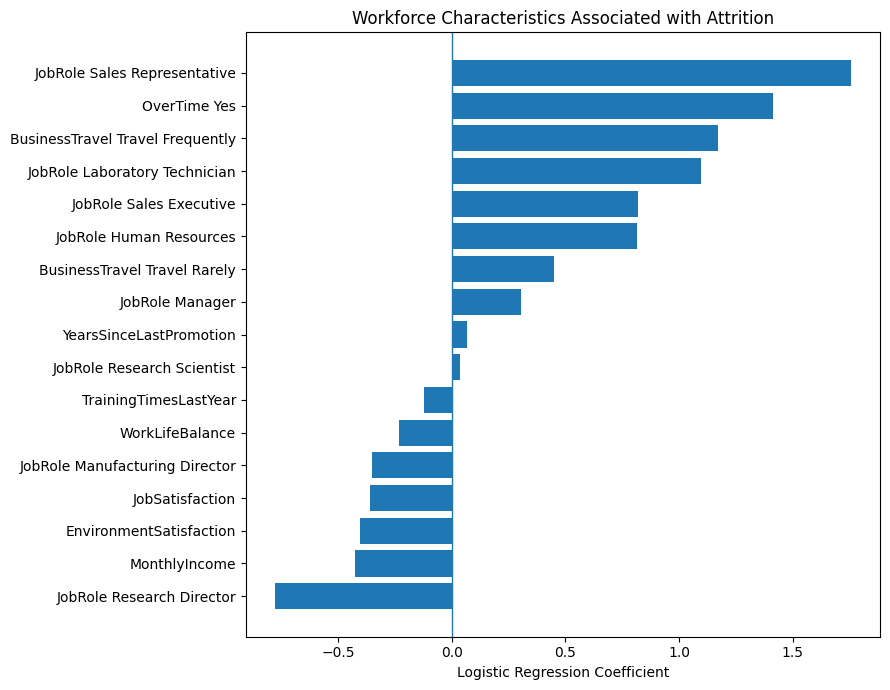

In [92]:
import matplotlib.pyplot as plt

plot_df = interpretation_df.copy()

plot_df["Feature"] = (
    plot_df["Feature"]
    .str.replace("_", " ", regex=False)
)

plot_df = plot_df.sort_values("Coefficient")

plt.figure(figsize=(9, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("")
plt.title("Workforce Characteristics Associated with Attrition")

plt.tight_layout()
plt.show()

### Interpretation of Multivariate Associations

The coefficient plot shows the direction and relative magnitude of
associations estimated by the logistic regression model.

Among the selected characteristics, overtime, frequent business travel
and several job roles show comparatively strong positive associations
with observed attrition.

Higher monthly income, environment satisfaction and job satisfaction
show negative associations with attrition. Years since last promotion
and training participation show comparatively weak associations in
the multivariate model.

These results broadly reinforce several patterns identified during the
exploratory analysis. Importantly, the coefficients represent conditional
associations within this specific model and synthetic dataset. They are
not causal effects, employee-level risk scores or direct measures of
feature importance.

## ROC Curve

The ROC curve evaluates the model's ability to distinguish between
employees with and without observed attrition across different
classification thresholds.

An AUC of 0.5 represents random discrimination, while higher values
indicate better separation between the two outcome groups.

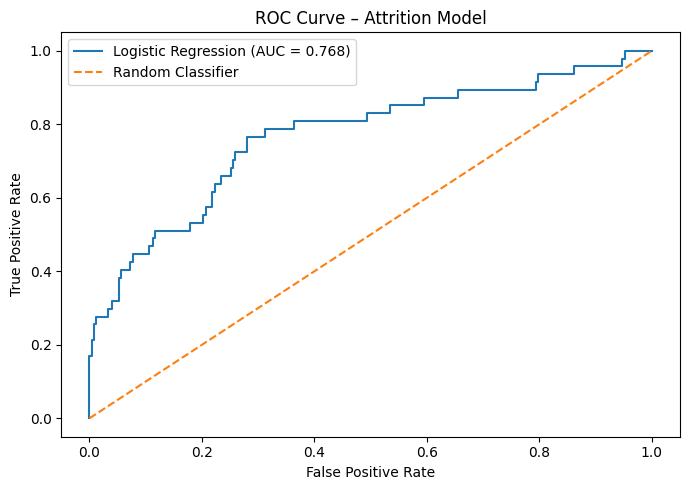

In [93]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Attrition Model")
plt.legend()

plt.tight_layout()
plt.show()

### ROC Curve Interpretation

The logistic regression achieves a ROC-AUC of 0.768, indicating a
meaningful but imperfect ability to distinguish between employees
with and without observed attrition.

The model performs better than random classification across a range
of decision thresholds. However, its performance is not sufficient
to justify individual employee-level decisions.

Combined with the low recall observed at the default threshold, the
ROC analysis reinforces the use of the model as an exploratory and
interpretive tool rather than an automated prediction system.

# Final Business Insights

The analysis suggests that employee attrition in this synthetic
workforce dataset is associated with a combination of working
conditions, organizational context, compensation and satisfaction
rather than with a single factor.

### 1. Overtime is one of the strongest and most consistent signals

Employees working overtime showed an observed attrition rate of 30.5%,
compared with 10.4% among employees without overtime.

Overtime also remained strongly associated with attrition in the
multivariate model (OR = 4.10), suggesting that workload patterns
deserve particular organizational attention.

### 2. Frequent business travel is associated with higher attrition

Observed attrition increased from 8.0% among non-travellers to 24.9%
among frequent travellers.

Frequent travel remained positively associated with attrition after
other selected characteristics were considered simultaneously
(OR = 3.22).

### 3. Attrition differs substantially across job roles

Sales Representatives showed the highest observed attrition rate
(39.8%). In the multivariate model, the Sales Representative role
also showed a strong positive association relative to the reference
role of Healthcare Representative (OR = 5.80).

Role differences should not be interpreted as causal, as roles may
also differ in workload, compensation, travel and other conditions.

### 4. Compensation is associated with attrition, but interacts with
workforce structure

Employees in the lowest income quartile showed substantially higher
observed attrition (29.3%).

Monthly income is strongly related to job level (r = 0.95), demonstrating
the importance of avoiding isolated interpretation of compensation.

However, within Job Level 1, employees in the lowest income quartile
still showed higher attrition (30.1%) than employees in the lower-middle
quartile (19.1%).

Higher standardized monthly income also showed a negative association
with attrition in the multivariate model (OR = 0.65).

### 5. Satisfaction matters, particularly at low levels

Low job satisfaction was associated with an observed attrition rate
of 22.8%, compared with 11.3% among employees reporting very high
job satisfaction.

Low environment satisfaction showed an attrition rate of 25.4%,
compared with 13.5% at the highest satisfaction level.

Both satisfaction measures retained negative associations with
attrition in the multivariate model.

### 6. Not every plausible HR hypothesis was supported

Years since last promotion did not show a consistent relationship
with attrition, and its multivariate association was weak (OR = 1.07).

Training participation showed only a moderate descriptive relationship
with attrition.

These findings illustrate the importance of testing plausible workforce
assumptions rather than treating them as established explanations.

# Recommendations

The results should be used to identify organizational areas for further
investigation rather than to make decisions about individual employees.

Based on the observed patterns, organizations could:

- Review overtime patterns across teams and roles and investigate whether
  sustained workload pressure is concentrated in particular areas.

- Examine the organizational impact of frequent business travel and
  explore whether workload, scheduling or recovery practices could be
  improved.

- Conduct deeper qualitative analysis in roles showing comparatively
  high attrition, particularly to understand working conditions,
  career expectations and role-specific challenges.

- Review compensation structures together with job level and career
  progression rather than interpreting salary in isolation.

- Use employee feedback and engagement data to investigate the reasons
  behind low job and environment satisfaction.

- Combine quantitative workforce analytics with interviews, surveys
  and organizational context before designing retention initiatives.

# Ethical Considerations and Limitations

This project uses a synthetic workforce dataset and is intended as a
demonstration of analytical methods rather than an assessment of real
employees.

Several limitations are important:

- Observed associations do not establish causality.
- The dataset may not represent the complexity of real organizations
  or labour markets.
- Some workforce characteristics are strongly related to each other,
  making isolated interpretation difficult.
- Model performance is moderate and recall for observed attrition is
  low at the default classification threshold.
- Logistic regression coefficients and odds ratios describe associations
  within this specific model and dataset; they should not be interpreted
  as universal effects.
- Employee-level attrition predictions could create fairness, privacy
  and discrimination risks if used operationally.

The model should therefore not be used to label employees as
"flight risks", automate employment decisions or determine access
to opportunities.

A responsible people analytics approach should focus on aggregate
organizational patterns, transparent analysis and human-led investigation
of working conditions.

# Conclusion

This project demonstrates an end-to-end workforce analytics workflow,
from business-oriented hypothesis formulation and data quality checks
to exploratory analysis, multivariate modelling and responsible
interpretation.

The results suggest that attrition is associated with a combination of
workload, travel, role, compensation and employee experience rather
than with a single workforce characteristic.

The analysis also demonstrates why workforce data requires careful
interpretation: several variables overlap, plausible hypotheses are not
always supported, and predictive performance alone does not justify
employee-level decisions.

The main value of people analytics is therefore not to predict who will
leave, but to identify organizational patterns that can guide deeper
investigation and better-informed workforce decisions.